/tmp/ipykernel_7679/3470403045.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2023-01-01")["Close"]
[*********************100%***********************]  2 of 2 completed


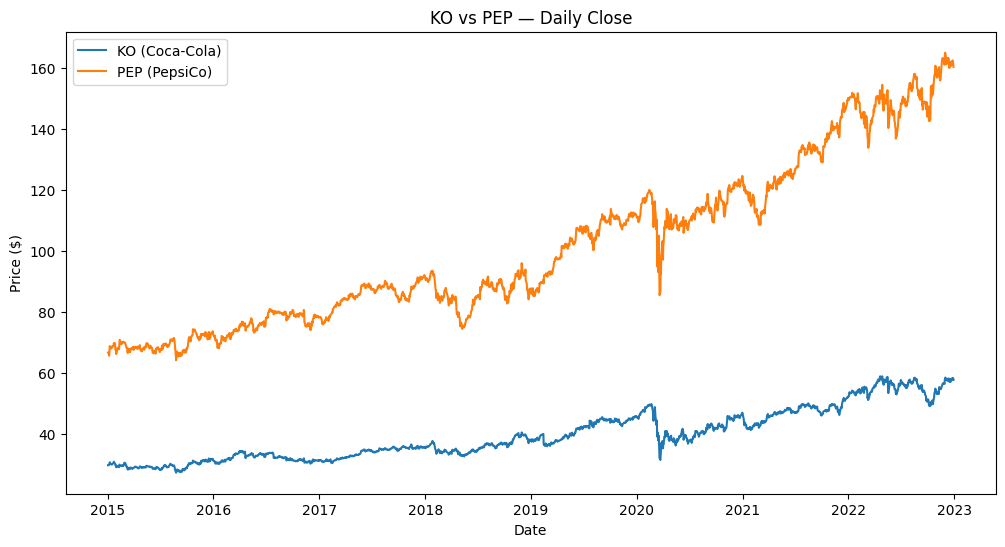

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Pull a few years of daily closing prices for our candidate pair
tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2015-01-01", end="2023-01-01")["Close"]

# Drop any rows with missing data so both series line up cleanly
data = data.dropna()

# Plot both price series to see them wander (non-stationary, no shared anchor by eye)
plt.figure(figsize=(12, 6))
plt.plot(data.index, data["KO"], label="KO (Coca-Cola)")
plt.plot(data.index, data["PEP"], label="PEP (PepsiCo)")
plt.title("KO vs PEP — Daily Close")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

Beta (hedge ratio): 0.3043


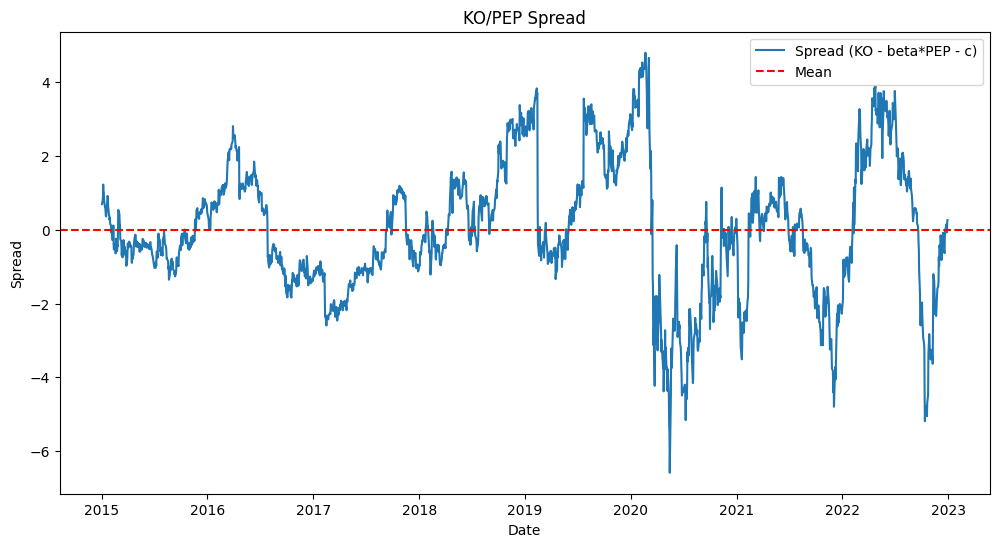

In [2]:
import statsmodels.api as sm

# Regress KO on PEP to find beta (the hedge ratio / conversion factor)
# We add a constant so the line can have an intercept, not be forced through origin
X = sm.add_constant(data["PEP"])   # PEP plus a column of 1s for the intercept
y = data["KO"]

model = sm.OLS(y, X).fit()
beta = model.params["PEP"]
print(f"Beta (hedge ratio): {beta:.4f}")

# The spread IS the regression residual: what's left of KO after removing beta*PEP
spread = y - model.predict(X)

# Plot the spread — THIS is where we look for stationarity (a flat home it reverts to)
plt.figure(figsize=(12, 6))
plt.plot(spread.index, spread, label="Spread (KO - beta*PEP - c)")
plt.axhline(spread.mean(), color="red", linestyle="--", label="Mean")
plt.title("KO/PEP Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

# Run the Augmented Dickey-Fuller test on the spread
# Dickey-Fuller Test : X_t = gamma*X_t-1 + e_t(Today's price = gamma*yesterday's price + noise) we want gamma to be negative in the mathematical version of the test to confirm that there is a leash which exists between the pair
# In ADF we just augment the same mathematical argument and it gives us a p- value: if p < 0.05 there is a leash -> no unit root -> stationarity confirmed -> possibility of a random walk is eliminated
# If p >= 0.05 we cannot fully rule out the possibility of a random walk

result = adfuller(spread)

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print("Critical Values:")
for level, value in critical_values.items():
    print(f"   {level}: {value:.4f}")

# The verdict
if p_value < 0.05:
    print("\n--> p < 0.05: reject unit root. Spread is STATIONARY. Leash exists -> tradeable.")
else:
    print("\n--> p >= 0.05: cannot reject unit root. Spread is NON-stationary. No reliable leash.")

ADF Statistic: -3.9088
p-value: 0.0020
Critical Values:
   1%: -3.4336
   5%: -2.8630
   10%: -2.5675

--> p < 0.05: reject unit root. Spread is STATIONARY. Leash exists -> tradeable.


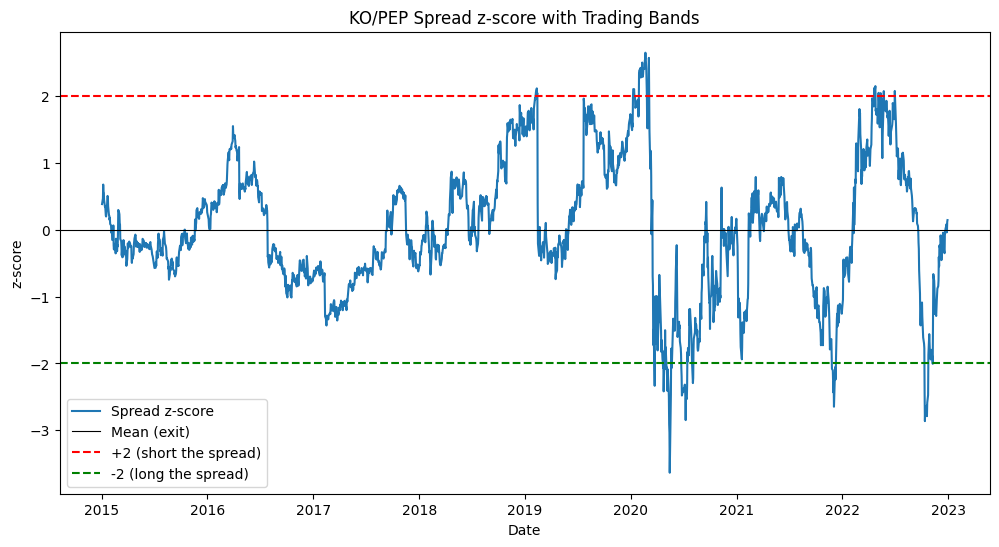

In [4]:
import numpy as np

# Convert the spread into a z-score: how many std devs from its mean z = (X-mean)/stddev

spread_mean = spread.mean()
spread_std = spread.std()
zscore = (spread - spread_mean) / spread_std

# Plot the z-score with entry/exit bands
plt.figure(figsize=(12, 6))
plt.plot(zscore.index, zscore, label="Spread z-score")
plt.axhline(0, color="black", linestyle="-", linewidth=0.8, label="Mean (exit)")
plt.axhline(2, color="red", linestyle="--", label="+2 (short the spread)")
plt.axhline(-2, color="green", linestyle="--", label="-2 (long the spread)")
plt.title("KO/PEP Spread z-score with Trading Bands")
plt.xlabel("Date")
plt.ylabel("z-score")
plt.legend()
plt.show()